In [ ]:
import os
import pickle
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams, cycler
from matplotlib.cm import ScalarMappable
import seaborn as sns
import tensorflow as tf
from scipy.stats import pearsonr, gaussian_kde, ecdf, ttest_rel, ttest_ind, ks_2samp
from sklearn.decomposition import PCA
import joblib
import sys
sys.path.append(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1]))
from sgcc import *

In [2]:
plt.rcParams['figure.dpi'] = 300
fontsize = 8
linewidth = 0.5

## Conditional optimization: Relaxed bounds and local perturbation restart

The purpose of this conditional optimization is to check the stability of the parameters found by the main optimization protocol. To test the stability:

1) Load the parameters from the main optimization protocol.
2) Apply a local perturbation to the loaded parameters by adding uniform noise.
3) Renormalize the perturbed parameters into an expanded boundary range.
4) Load the perturbed renormalized parameters into a new instance of the model with relaxed parameter bounds.
5) Reoptimize.
6) Check if the loss and parameter distributions have diverged from the those of the main optimization protocol.

In [3]:
X = tf.convert_to_tensor([0.02,0.04,0.08,0.1,0.12,0.16,0.2,0.24,0.28,0.32], dtype = tf.float32)

In [4]:
v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'v1_ori_phase_condition_pcascores_wcomp.pkl')
v1_scores = pd.read_pickle(v1_xs_file)
v1_scores_condition_averaged = np.array([np.array(x) for x in v1_scores.scores.values]).mean(0)
Y_true = v1_scores_condition_averaged[:2,:,:].transpose(0,2,1)

In [5]:
param_bounds = {
    "fts": [0, 175],
    "t": [40, 125],
    "ampc": [0.01, 0.1],
    'ampm': [0,3],
    "ampg": [0.1, 4],
    "ampw": [0.01,0.08],
    "d": [10, 40],
    "inh_d": [0, 40],
    "inh_w": [0, 3],
}

relaxed_param_bounds = {
    "fts": [-200.0, 200.0],
    "t": [1, 200.0],
    "ampc": [0.01, 1.0],
    'ampm': [-10.0, 10.0],
    "ampg": [-10, 10.0],
    "ampw": [0.0, 1.0],
    "d": [0, 200.0],
    "inh_d": [0, 100.0],
    "inh_w": [-10.0, 10.0],
}

In [6]:
P = joblib.load(
    os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'best_permutation.pkl')
)

In [7]:
sgcc = SGCCircuit(param_bounds, enforce_permutation=P)

In [8]:
modfile = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'sgcc_mop_4_18_26.pkl')
with open(modfile, 'rb') as f:
    optimized_model = pickle.load(f)

In [9]:
sgcc.load_saved_parameters(
        {x[0]:x[1] + tf.random.uniform(x[1].shape, -1, 1) 
        for x in optimized_model['final_epoch_params'].items()}
    
    )

In [10]:
def renorm(sgcc, newbounds):

    dlgn_bounds = tf.convert_to_tensor([x for x in newbounds.values()])[:-2]
    dlgn_lower = tf.reshape(dlgn_bounds[:,0], [1,1,1,-1,1,1])
    dlgn_upper = tf.reshape(dlgn_bounds[:,1], [1,1,1,-1,1,1])

    v1_bounds = tf.convert_to_tensor([x for x in newbounds.values()])[-2:]
    v1_lower = tf.reshape(v1_bounds[:,0], [1,1,1,-1,1,1])
    v1_upper = tf.reshape(v1_bounds[:,1], [1,1,1,-1,1,1])

    params = {
        'dLGN_params': sgcc.inverse_dlgn_property(
            sgcc.variable_transformer(sgcc.params['dLGN_params'], dlgn_lower, dlgn_upper, 'normalize')
        ),
        'V1_params': sgcc.variable_transformer(sgcc.params['V1_params'], v1_lower, v1_upper, 'normalize')
    }

    return params

In [11]:
renormed_params = renorm(sgcc, relaxed_param_bounds)

In [12]:
model = SGCCircuit(relaxed_param_bounds, enforce_permutation=P)

In [13]:
model.load_saved_parameters(renormed_params)

In [14]:
# initialize the optimizer
optimizer = Optimize(model, epochs=1000, loss_threshold=0)

# fit the model
loss_decay = optimizer.fit(X, Y_true)

Optimizer initialized with <keras.optimizers.optimizer_v2.adam.Adam object at 0x000002768A4803A0>
Training step = 0, N_exploration_samples = 4000,
min_loss = 0.16425007581710815
med_loss = 0.8860291838645935
max_loss = 5.586416244506836

Training step = 100, N_exploration_samples = 4000,
min_loss = 0.08023716509342194
med_loss = 0.22683750092983246
max_loss = 1.565988540649414

Training step = 200, N_exploration_samples = 4000,
min_loss = 0.07399661839008331
med_loss = 0.12979699671268463
max_loss = 0.6382921934127808

Training step = 300, N_exploration_samples = 4000,
min_loss = 0.07099315524101257
med_loss = 0.10112776607275009
max_loss = 0.3317943215370178

Training step = 400, N_exploration_samples = 4000,
min_loss = 0.0685732439160347
med_loss = 0.08972306549549103
max_loss = 0.2891571819782257

Training step = 500, N_exploration_samples = 4000,
min_loss = 0.06710103899240494
med_loss = 0.0836307480931282
max_loss = 0.27607178688049316

Training step = 600, N_exploration_samples =

In [15]:
optimizer.save_state(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'sgcc_mop_4_18_26_reopt'))

In [16]:
loss_decay = loss_decay.numpy()
param_history = optimizer.outputs['param_history']

In [17]:
last_epoch = loss_decay[-1]
best = np.where(last_epoch == last_epoch.min())[0][0]
print(f"Index of best parameters: {best}, loss = {last_epoch[best]}")

Index of best parameters: 2002, loss = 0.06414794921875


In [18]:
def minmax_norm(array, lower, upper):
    if (array.max() - array.min()) != 0:
        norm = (array - array.min()) / (array.max() - array.min())
        return lower + (norm * (upper-lower))
    else:
        return array

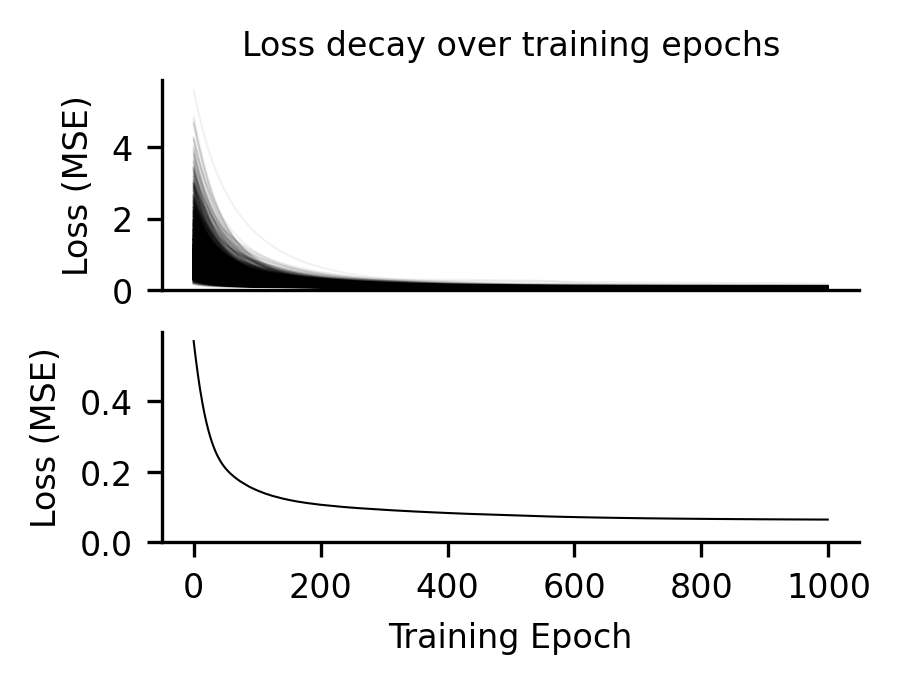

In [ ]:
fig, ax = plt.subplots(2, figsize = (3,2))

for i, decay in enumerate(loss_decay.T):
    ax[0].plot(decay, alpha = 0.05, color = 'black', linewidth = linewidth)

ax[1].set_xlabel("Training Epoch", fontsize = fontsize)
ax[0].set_ylabel("Loss (MSE)", fontsize = fontsize)
ax[0].set_ylim(0,)
ax[0].set_xticks([])

ax[1].set_ylabel("Loss (MSE)", fontsize = fontsize)
ax[1].plot(loss_decay[:,best], alpha = 1, color = 'black', linewidth = linewidth)
ax[1].set_ylim(0.)
ax[0].set_title("Loss decay over training epochs", fontsize = fontsize)

for i in range(2):
    ax[i].tick_params(labelsize = fontsize)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)

# figname = '2d_model_loss_decay_first_round.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

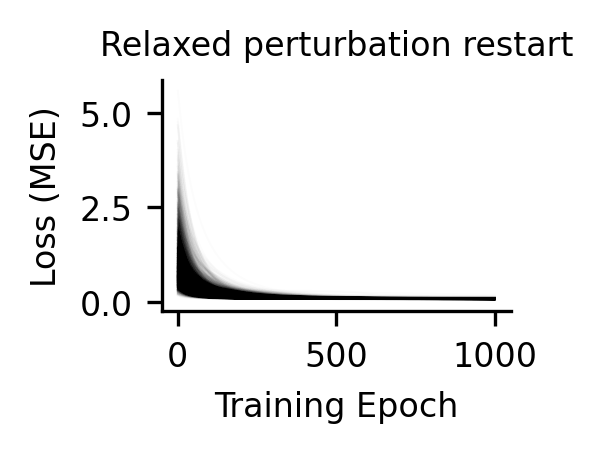

In [20]:
fig, ax = plt.subplots(1, figsize = (1.5,1))

ax.plot(loss_decay, alpha = 0.01, color = 'black', linewidth = linewidth)
ax.set_xlabel("Training Epoch", fontsize = fontsize)
ax.set_ylabel("Loss (MSE)", fontsize = fontsize)
ax.set_ylim(-0.25,)
#ax.set_xticks([])
ax.set_title("Relaxed perturbation restart", fontsize = fontsize)


ax.tick_params(labelsize = fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

figname = '2d_model_loss_decay_2nd_round_4_18.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

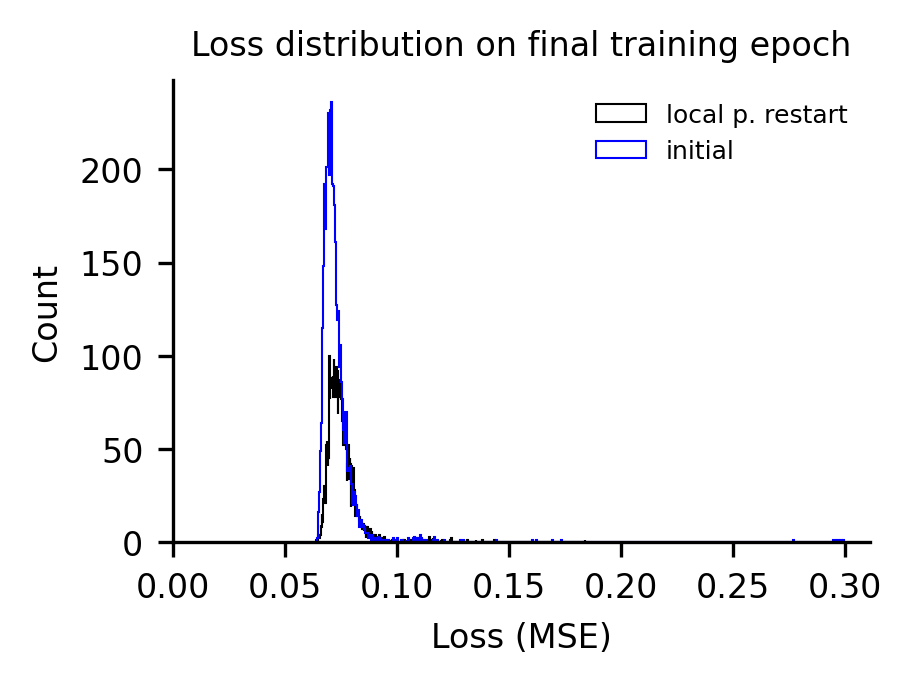

In [21]:
fig, ax = plt.subplots(figsize = (3,2))
ax.hist(loss_decay[-1], bins = 500, color = 'black', histtype='step', linewidth = 0.5, label = 'local p. restart')
ax.hist(optimized_model['loss_decay'][-1], bins = 500, linewidth = 0.5, color = 'blue', histtype='step', label = 'initial')
ax.tick_params(labelsize = fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("Count", fontsize = fontsize)
ax.set_xlabel("Loss (MSE)", fontsize = fontsize)
ax.set_xticks(np.arange(0,0.35,0.05))
#ax.set_ylim(0,60)
ax.set_title("Loss distribution on final training epoch", fontsize = fontsize)
ax.legend(fontsize = 6, frameon = False)
figname = 'loss_dist_first_round_v_post_restart.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

Text(0.525, 1.05, 'Distribution of V1 parameters post-optimization')

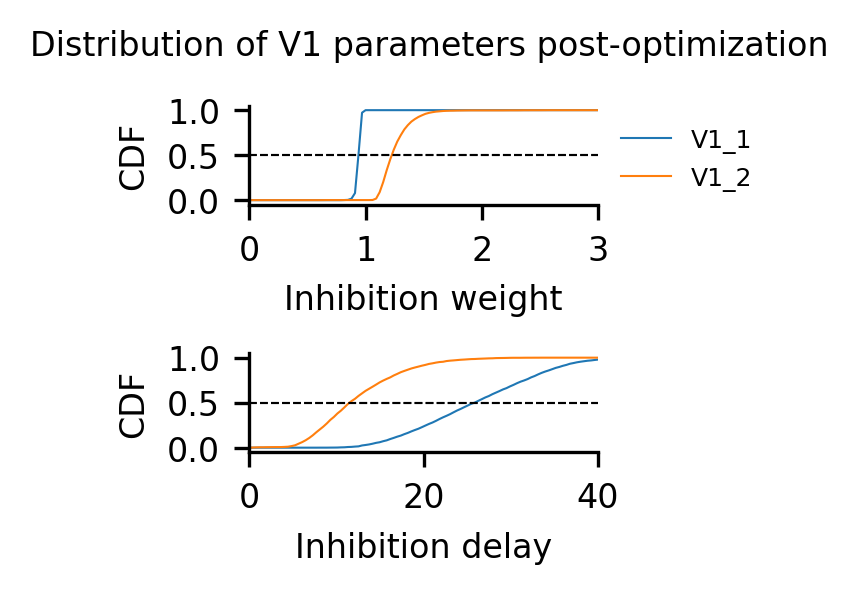

In [22]:
fig, ax = plt.subplots(2,1, figsize = (1.5, 1.5))

for i in range(2):
    i_ = np.abs(i-1)
    for u in range(2):
        x = np.linspace(
            list(param_bounds.values())[-1-i][0],
            list(param_bounds.values())[-1-i][1],
            100
        )
        data = param_history['V1_params'][:,-1,u,0,i_,0,0]
        kde = ecdf(data).cdf
        y = kde.evaluate(x)

        ax[i].plot(x,y, label = f'V1_{u+1}', linewidth = linewidth)
        ax[i].plot(x, np.full(len(x), 0.5), '--', color = 'black', linewidth = linewidth)
        ax[i].set_xlim(
            list(param_bounds.values())[-1-i][0],
            list(param_bounds.values())[-1-i][1]
        )
        ax[i].set_ylabel("CDF", fontsize = fontsize)
        ax[i].set_yticks(np.arange(0, 1.5, 0.5))
        ax[i].spines['top'].set_visible(False)
        ax[i].spines['right'].set_visible(False)
        ax[i].tick_params(labelsize = fontsize)

ax[0].set_xlabel('Inhibition weight', fontsize = fontsize)
ax[1].set_xlabel('Inhibition delay', fontsize = fontsize)
ax[0].legend(fontsize = 6, frameon = False, bbox_to_anchor = (1,1))
fig.subplots_adjust(hspace=1.5)
plt.suptitle("Distribution of V1 parameters post-optimization", fontsize = fontsize, x = 0.525, y = 1.05)

# figname = '2d_model_v1_param_density_func_first_round.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

Text(0.525, 0.975, 'Distribution of dLGN parameters post-optimization')

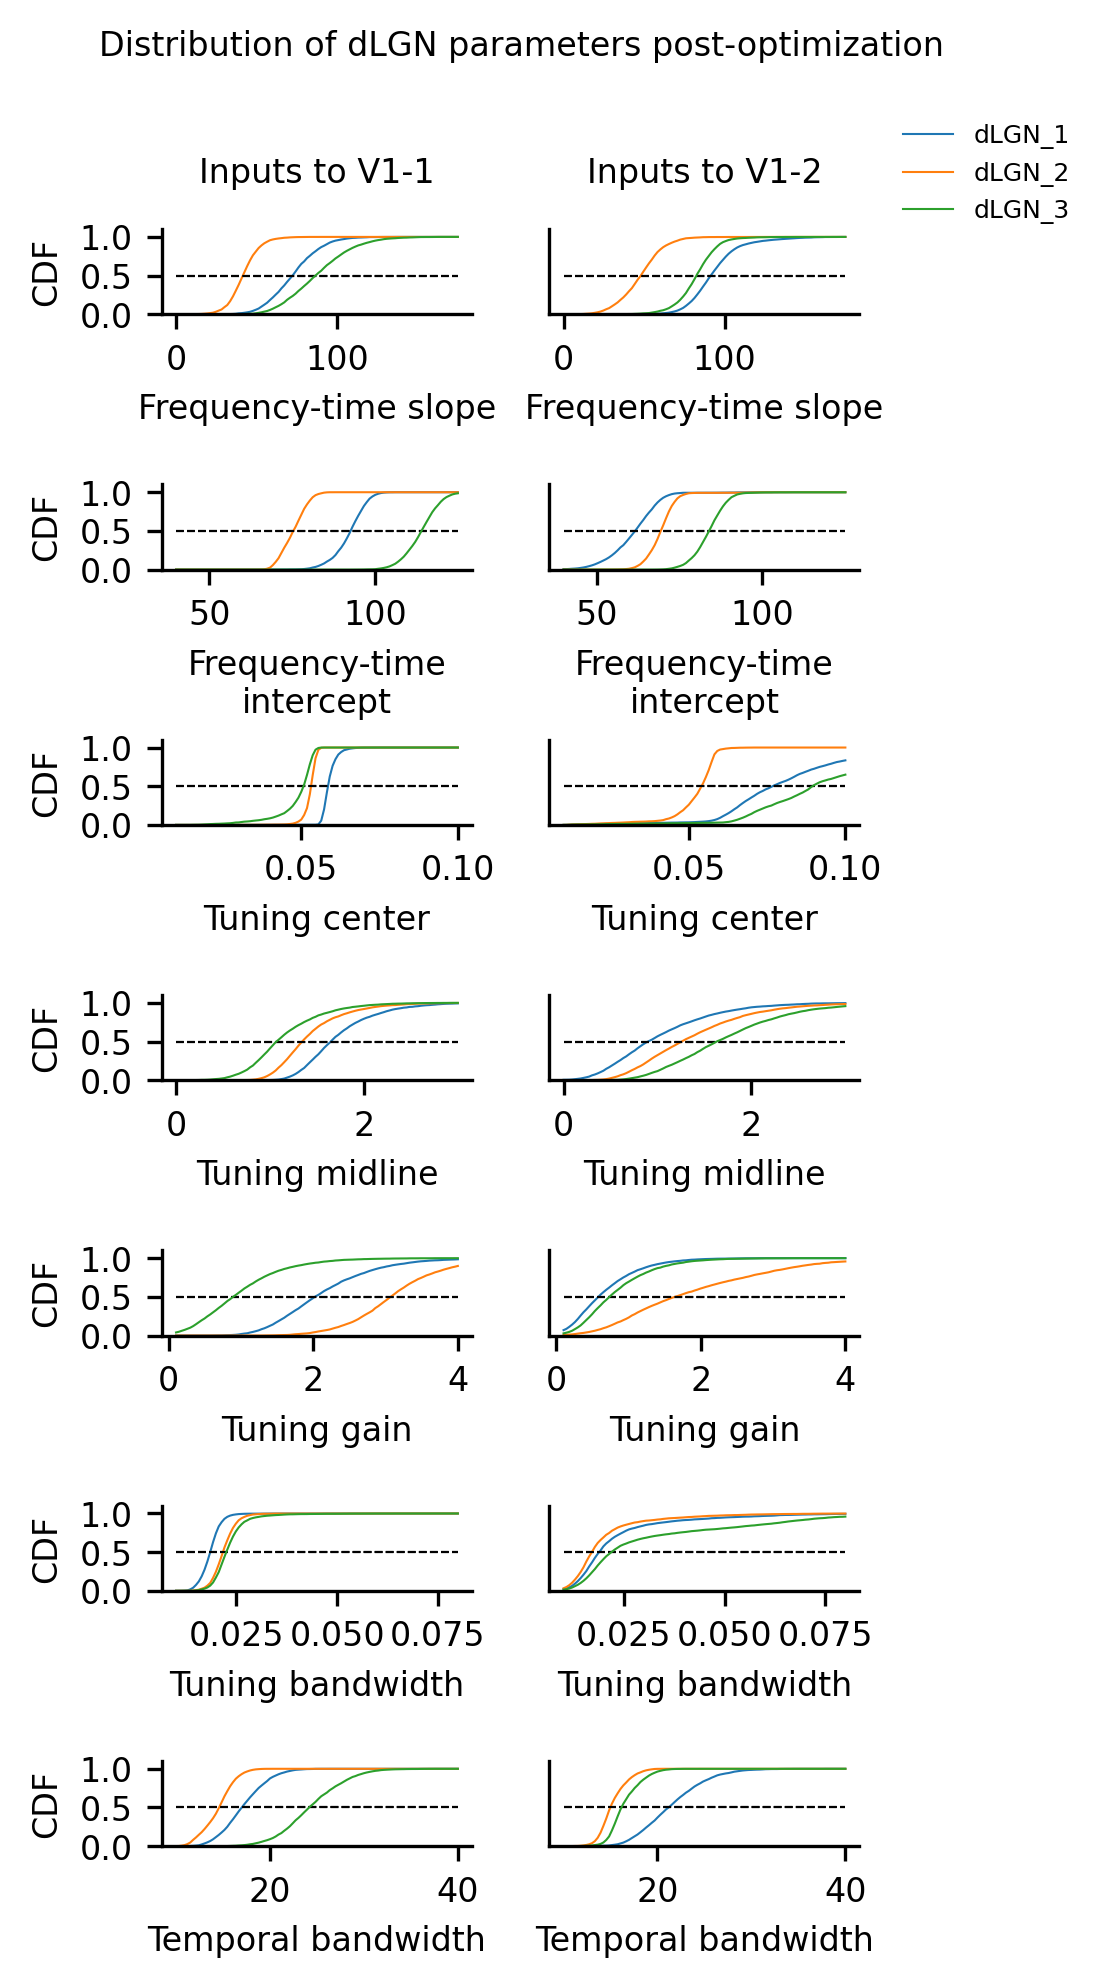

In [23]:
fig, ax = plt.subplots(7,2, figsize = (3,7))

param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            data = param_history['dLGN_params'][:,-1,u,i,row,0,0]
            x = np.linspace(
                list(param_bounds.values())[:7][row][0],
                list(param_bounds.values())[:7][row][1], 
                100
            )
            kde = ecdf(data).cdf
            y = kde.evaluate(x)

            ymax.append(y.max())

            ax[row, u].plot(x, np.full(len(x), 0.5), '--', color = 'black', linewidth = linewidth)
            ax[row, u].plot(x, y, label = neuron_labels[i], linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("CDF", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, 1.1)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Distribution of dLGN parameters post-optimization", fontsize = fontsize, x = 0.525, y = 0.975)

# figname = '2d_model_dlgn_param_density_func_first_round.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

Text(0.525, 0.975, 'Distribution of dLGN parameters post-optimization')

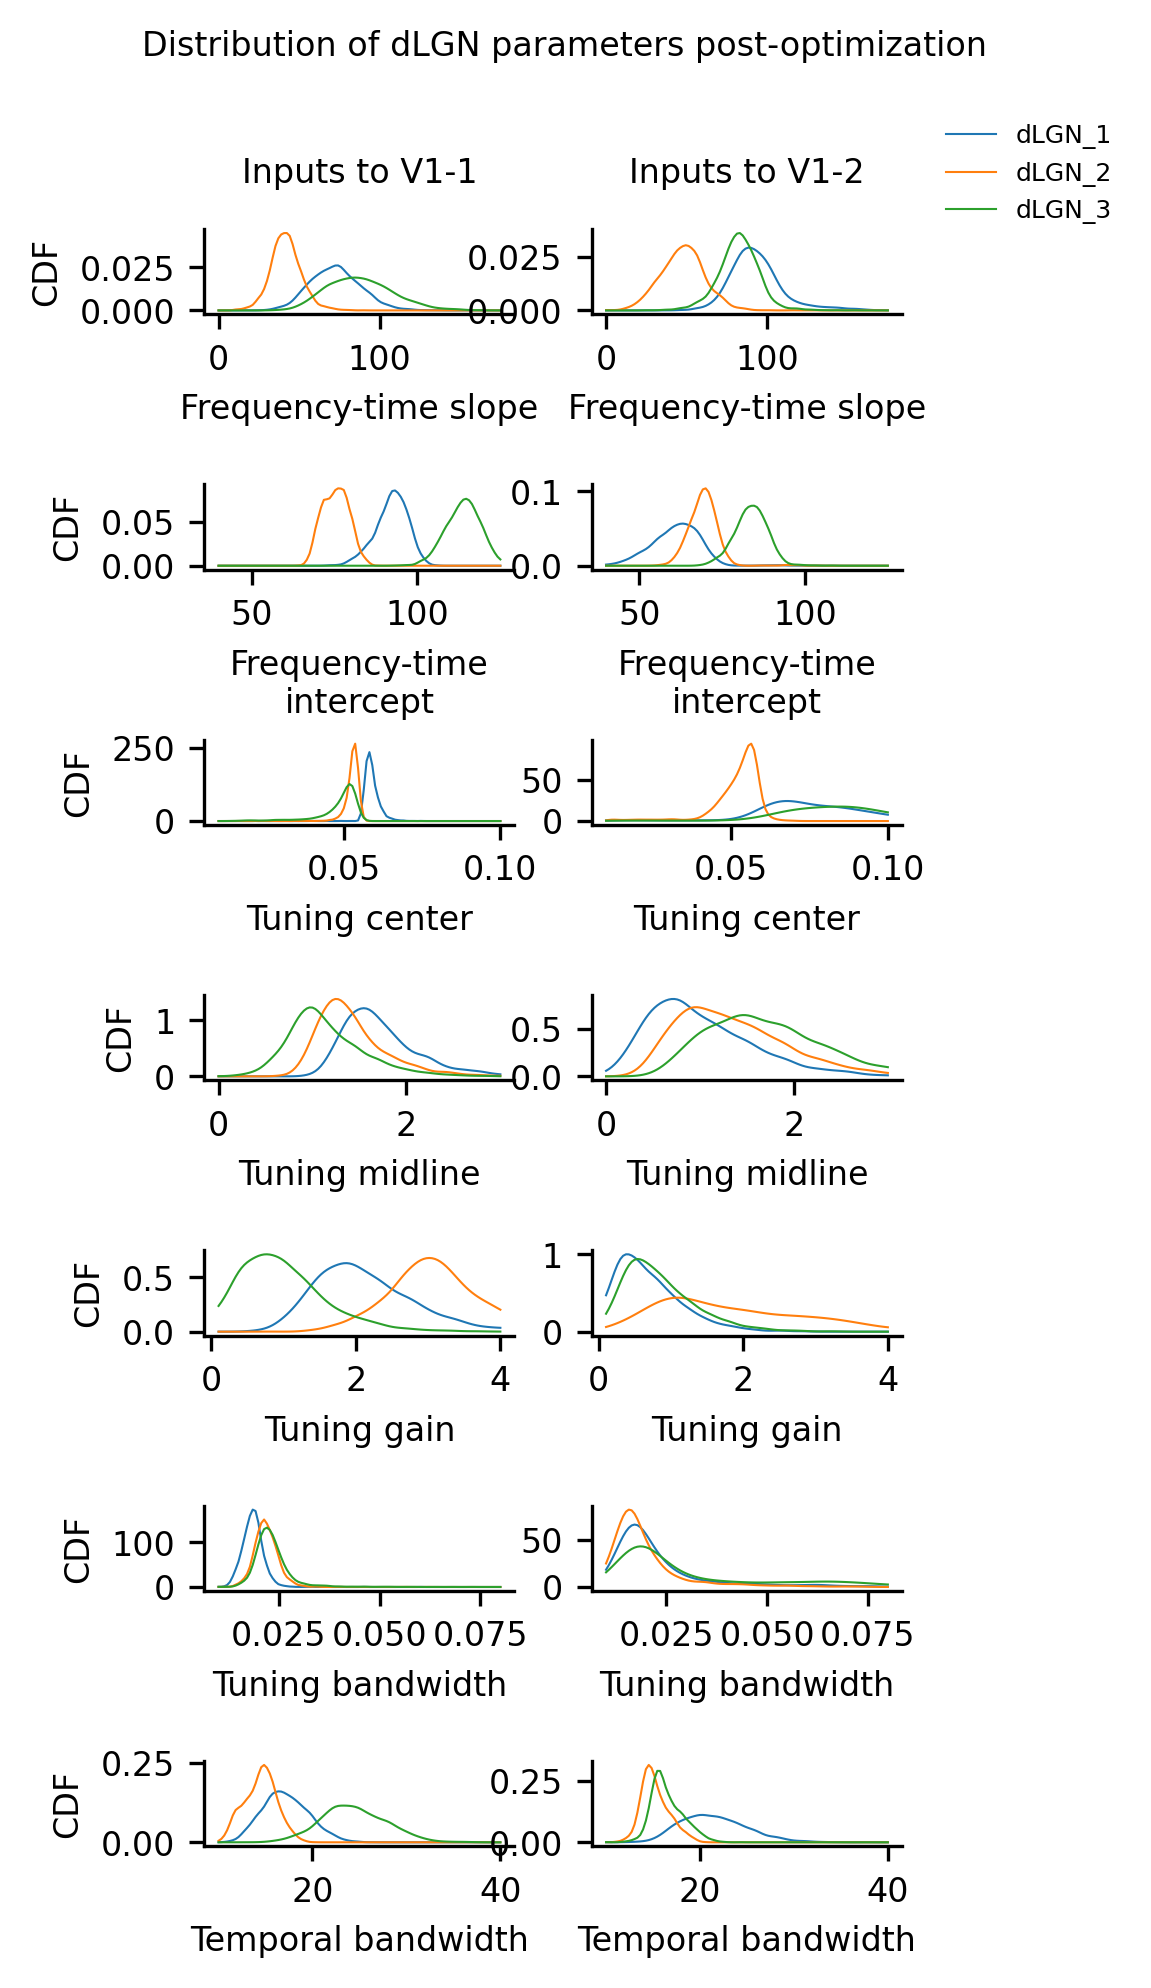

In [24]:
fig, ax = plt.subplots(7,2, figsize = (3,7))

param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            data = param_history['dLGN_params'][:,-1,u,i,row,0,0]
            x = np.linspace(
                list(param_bounds.values())[:7][row][0],
                list(param_bounds.values())[:7][row][1], 
                100
            )
            kde = gaussian_kde(data)
            #kde = ecdf(data).cdf
            y = kde.evaluate(x)
            #y = y/y.max()

            ymax.append(y.max())

            #ax[row, u].plot(x, np.full(len(x), 0.5), '--', color = 'black', linewidth = linewidth)
            ax[row, u].plot(x, y, label = neuron_labels[i], linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("CDF", fontsize = fontsize)
    for u in range(2):
        #ax[row, u].set_ylim(0, 1.1)
        #ax[row, 1].set_yticks([])
        #ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Distribution of dLGN parameters post-optimization", fontsize = fontsize, x = 0.525, y = 0.975)

# figname = '2d_model_dlgn_param_density_func_first_round.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

In [25]:
## Credit goes to skynaut (2015) on Stackoverflow: https://stackoverflow.com/questions/21532471/how-to-calculate-cohens-d-in-python
def cohensd(x,y):
    if len(x) == len(y):
        return (np.mean(x) - np.mean(y)) / np.sqrt((np.std(x, ddof=1) ** 2 + np.std(y, ddof=1) ** 2) / 2.0)
    else:
        nx = len(x)
        ny = len(y)
        dof = nx + ny - 2
        return (np.mean(x) - np.mean(y)) / np.sqrt(((nx-1)*np.std(x, ddof=1) ** 2 + (ny-1)*np.std(y, ddof=1) ** 2) / dof)

In [26]:
totalcd = cohensd(optimized_model['param_history']['dLGN_params'][:,-1,:,:,:,0,0].flatten().astype(np.float64), 
          param_history['dLGN_params'][:,-1,:,:,:,0,0].flatten().astype(np.float64))

In [30]:
totalcd

-0.0015666052137742884

In [27]:
ttest_rel(optimized_model['param_history']['dLGN_params'][:,-1,:,:,:,0,0].flatten().astype(np.float64), 
          param_history['dLGN_params'][:,-1,:,:,:,0,0].flatten().astype(np.float64), alternative = 'two-sided')

TtestResult(statistic=-4.940199406327879, pvalue=7.811750240493287e-07, df=167999)

In [28]:
ks_2samp(optimized_model['param_history']['dLGN_params'][:,-1,:,:,:,0,0].flatten().astype(np.float64), 
          param_history['dLGN_params'][:,-1,:,:,:,0,0].flatten().astype(np.float64), alternative = 'two-sided')

KstestResult(statistic=0.01619642857142861, pvalue=1.4312246444579913e-19, statistic_location=0.546875, statistic_sign=-1)

Text(0.5, 1.0, "Cohen's d = -0.0")

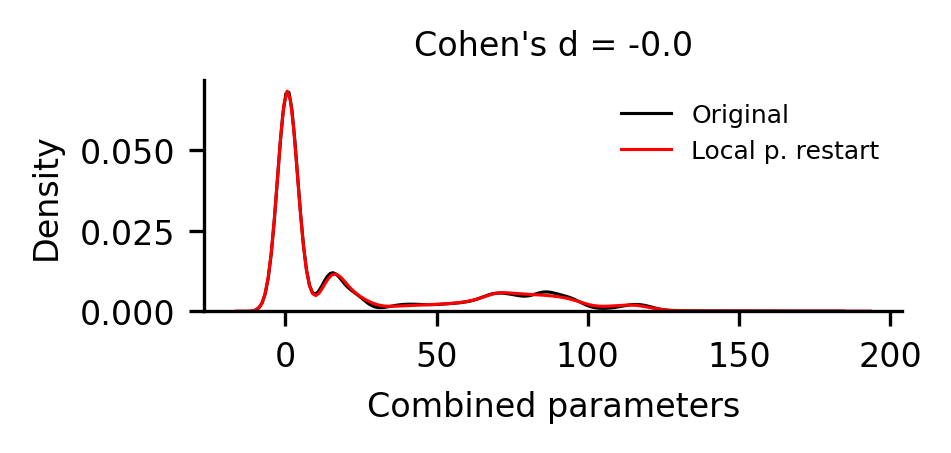

In [29]:
fig, ax = plt.subplots(figsize = (3,1))
sns.kdeplot(
    optimized_model['param_history']['dLGN_params'][:,-1,:,:,:,0,0].flatten(), 
    linewidth = 0.75, color = 'black', label = 'Original', ax = ax
)
sns.kdeplot(
    param_history['dLGN_params'][:,-1,:,:,:,0,0].flatten(), 
    linewidth = 0.75, color = 'red', label = "Local p. restart", ax = ax
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize = 8)
ax.legend(fontsize = 6, frameon = False)
ax.set_xlabel("Combined parameters", fontsize = 8)
ax.set_ylabel("Density", fontsize = 8)
ax.set_title(f"Cohen's d = {totalcd.round(2)}", fontsize = 8)
# figname = 'parameter_dist_pre_vs_post_restart.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

In [28]:
for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            param = list(param_bounds.keys())[:7][row]
            data_pre = optimized_model['param_history']['dLGN_params'][:,-1,u,i,row,0,0]
            data_post = param_history['dLGN_params'][:,-1,u,i,row,0,0]
            comp = cohensd(data_pre, data_post).round(2)
            print(f"{param}_V1_{u+1}_dLGN{i+1} pre and post comparison: {comp}")

fts_V1_1_dLGN1 pre and post comparison: -0.0
fts_V1_2_dLGN1 pre and post comparison: 0.0
fts_V1_1_dLGN2 pre and post comparison: -0.0
fts_V1_2_dLGN2 pre and post comparison: 0.0
fts_V1_1_dLGN3 pre and post comparison: -0.0
fts_V1_2_dLGN3 pre and post comparison: 0.0
t_V1_1_dLGN1 pre and post comparison: 0.0
t_V1_2_dLGN1 pre and post comparison: -0.0
t_V1_1_dLGN2 pre and post comparison: -0.0
t_V1_2_dLGN2 pre and post comparison: -0.0
t_V1_1_dLGN3 pre and post comparison: 0.0
t_V1_2_dLGN3 pre and post comparison: 0.0
ampc_V1_1_dLGN1 pre and post comparison: -0.13
ampc_V1_2_dLGN1 pre and post comparison: -0.39
ampc_V1_1_dLGN2 pre and post comparison: 0.01
ampc_V1_2_dLGN2 pre and post comparison: -0.14
ampc_V1_1_dLGN3 pre and post comparison: 0.04
ampc_V1_2_dLGN3 pre and post comparison: -0.6
ampm_V1_1_dLGN1 pre and post comparison: 0.25
ampm_V1_2_dLGN1 pre and post comparison: 0.06
ampm_V1_1_dLGN2 pre and post comparison: 0.21
ampm_V1_2_dLGN2 pre and post comparison: 0.06
ampm_V1_1_dLGN3

c:\Users\Sturdy\anaconda3\envs\tf\lib\site-packages\numpy\core\_methods.py:152: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)


In [29]:
res = param_history['dLGN_params'].squeeze()
print(res.shape[2:])
n_samples, n_epochs = res.shape[:2]
n_params = np.prod(res.shape[2:])# + np.prod(r2.shape[2:])

res = res.reshape(res.shape[0] * res.shape[1], np.prod(res.shape[2:]))
pca = PCA() # all epochs included
res_transformed_pca = pca.fit_transform(res).reshape(n_samples, n_epochs, n_params)

(2, 3, 7)


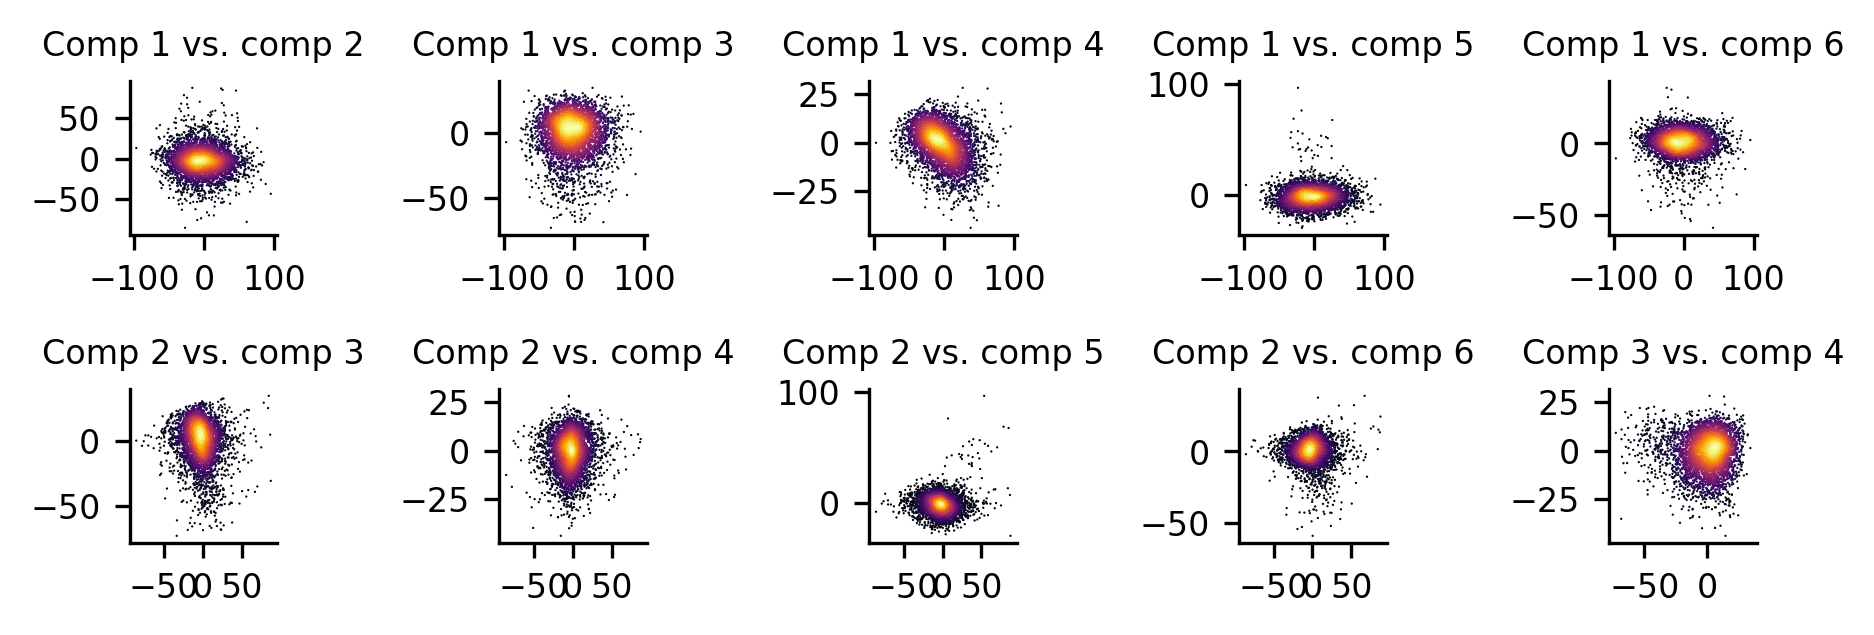

In [ ]:
fig, ax = plt.subplots(2,5, figsize = (7,2))



comp_pairs = (list(combinations(np.arange(6), 2)))
i = 0
for row in range(2):
    for col in range(5):



        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        c0, c1 = comp_pairs[i]
        
        data = np.array([
            res_transformed_pca[:,-1,c0], 
            res_transformed_pca[:,-1,c1]
        ])

        kde = gaussian_kde(data)
        density = kde(data)
        cmap = plt.get_cmap('inferno')(minmax_norm(density, 0, 1))

        ax[row, col].scatter(res_transformed_pca[:,-1,c0], res_transformed_pca[:,-1,c1], s = 0.3, color = cmap, linewidth = 0, rasterized=True) # last epoch
        ax[row, col].set_title(f"Comp {c0+1} vs. comp {c1+1}", fontsize = fontsize)
        i+=1

fig.subplots_adjust(hspace = 1, wspace = 1.5)
# figname = 'parameter_pca_projection_post_restart.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)